In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)  # reproducibility

# --- Business list ---
businesses = [
    ("B001", "Bakery"),
    ("B002", "Restaurant"),
    ("B003", "FuelStation"),
    ("B004", "Pharmacy"),
    ("B005", "Supermarket"),
    ("B006", "SmallShop"),
]

months = ["2024-01","2024-02","2024-03"]

# --- Rules for ranges ---
fuel_rules = {
    "Bakery": {"diesel": (200, 400)},
    "Restaurant": {"LPG": (60, 120), "petrol": (20, 60)},
    "FuelStation": {"diesel": (600, 1200), "petrol": (400, 900)},
    "Pharmacy": {"petrol": (50, 100)},
    "Supermarket": {"diesel": (400, 800), "petrol": (100, 300)},
    "SmallShop": {"petrol": (30, 70)},
}

# --- Generate synthetic dataset ---
rows = []
for bid, btype in businesses:
    for month in months:
        fuels = fuel_rules[btype]
        for ftype, (low, high) in fuels.items():
            liters = np.random.randint(low, high+1)
            rows.append([bid, btype, month, ftype, liters])

fuel_df = pd.DataFrame(rows, columns=["business_id","business_type","reporting_month","fuel_type","liters"])

# --- Save CSV ---
fuel_df.to_csv("fuel.csv", index=False)

print("fuel.csv created with", len(fuel_df), "rows")
print(fuel_df.head(12))


fuel.csv created with 27 rows
   business_id business_type reporting_month fuel_type  liters
0         B001        Bakery         2024-01    diesel     302
1         B001        Bakery         2024-02    diesel     379
2         B001        Bakery         2024-03    diesel     292
3         B002    Restaurant         2024-01       LPG      74
4         B002    Restaurant         2024-01    petrol      27
5         B002    Restaurant         2024-02       LPG     120
6         B002    Restaurant         2024-02    petrol      40
7         B002    Restaurant         2024-03       LPG      98
8         B002    Restaurant         2024-03    petrol      38
9         B003   FuelStation         2024-01    diesel     814
10        B003   FuelStation         2024-01    petrol     730
11        B003   FuelStation         2024-02    diesel    1058


In [2]:
fuel_df.shape

(27, 5)

In [6]:
import pandas as pd

data=[
    {'fuel_type': 'diesel', 'unit': 'liter', 'emission_factor': '2.68'},
    {'fuel_type': 'petrol', 'unit': 'liter', 'emission_factor': '2.33'},
    {'fuel_type': 'LPG', 'unit': 'kg', 'emission_factor': '3.01'},
    {'fuel_type': 'kerosene', 'unit': 'kg', 'emission_factor': '2.60'}
]

df = pd.DataFrame(data)

# Save to CSV
df.to_csv("fuel_emission_factors.csv", index=False)

print("fuel_emission_factors.csv created")
print(df)

fuel_emission_factors.csv created
  fuel_type   unit emission_factor
0    diesel  liter            2.68
1    petrol  liter            2.33
2       LPG     kg            3.01
3  kerosene     kg            2.60


In [7]:
df.head()

,fuel_type,unit,emission_factor
0,diesel,liter,2.68
1,petrol,liter,2.33
2,LPG,kg,3.01
3,kerosene,kg,2.60


In [8]:
import pandas as pd

# --- LOAD DATA ---
fuel = pd.read_csv("fuel.csv")
factors = pd.read_csv("fuel_emission_factors.csv")

# --- MERGE ON FUEL TYPE ---
df_fuel = fuel.merge(factors, how="left", on="fuel_type")

# --- CALCULATE EMISSIONS ---
df_fuel["emissions_kgCO2e"] = df_fuel["liters"] * df_fuel["emission_factor"]

# --- SAVE OUTPUT ---
df_fuel.to_csv("fuel_emissions_summary.csv", index=False)

print("fuel_emissions_summary.csv created with", len(df_fuel), "rows")
print(df_fuel.head(10))


fuel_emissions_summary.csv created with 27 rows
  business_id business_type reporting_month fuel_type  liters   unit  \
0        B001        Bakery         2024-01    diesel     302  liter   
1        B001        Bakery         2024-02    diesel     379  liter   
2        B001        Bakery         2024-03    diesel     292  liter   
3        B002    Restaurant         2024-01       LPG      74     kg   
4        B002    Restaurant         2024-01    petrol      27  liter   
5        B002    Restaurant         2024-02       LPG     120     kg   
6        B002    Restaurant         2024-02    petrol      40  liter   
7        B002    Restaurant         2024-03       LPG      98     kg   
8        B002    Restaurant         2024-03    petrol      38  liter   
9        B003   FuelStation         2024-01    diesel     814  liter   

   emission_factor  emissions_kgCO2e  
0             2.68            809.36  
1             2.68           1015.72  
2             2.68            782.56  
3  

In [9]:
df_fuel.head(10)

,business_id,business_type,reporting_month,fuel_type,liters,unit,emission_factor,emissions_kgCO2e
0,B001,Bakery,2024-01,diesel,302,liter,2.68,809.36
1,B001,Bakery,2024-02,diesel,379,liter,2.68,1015.72
2,B001,Bakery,2024-03,diesel,292,liter,2.68,782.56
3,B002,Restaurant,2024-01,LPG,74,kg,3.01,222.74
4,B002,Restaurant,2024-01,petrol,27,liter,2.33,62.91
5,B002,Restaurant,2024-02,LPG,120,kg,3.01,361.20
6,B002,Restaurant,2024-02,petrol,40,liter,2.33,93.20
7,B002,Restaurant,2024-03,LPG,98,kg,3.01,294.98
8,B002,Restaurant,2024-03,petrol,38,liter,2.33,88.54
9,B003,FuelStation,2024-01,diesel,814,liter,2.68,2181.52


In [11]:
fuel_summary = df_fuel.groupby("business_type")["emissions_kgCO2e"].sum().reset_index()
print(fuel_summary)


  business_type  emissions_kgCO2e
0        Bakery           2607.64
1   FuelStation          11620.20
2      Pharmacy            498.62
3    Restaurant           1123.57
4     SmallShop            356.49
5   Supermarket           6412.76


In [15]:
df_fuel.shape

(27, 8)

In [14]:
from google.colab import files
files = files.upload()

Saving emissions_summary.csv to emissions_summary.csv


In [27]:
import pandas as pd

# Load both summaries
elec = pd.read_csv("emissions_summary.csv")              # electricity
fuel = pd.read_csv("fuel_emissions_summary.csv")         # fuel

# Make columns consistent
elec["source_type"] = "electricity"
fuel["source_type"] = "fuel"

# Combine
all_emissions = pd.concat([elec, fuel], ignore_index=True)

# Save master dataset
all_emissions.to_csv("all_emissions.csv", index=False)

print("✅ all_emissions.csv created with", len(all_emissions), "rows")
print(all_emissions.head(10))


✅ all_emissions.csv created with 1467 rows
  business_id business_type billing_period  consumption_kWh     source  \
0       B0001        Bakery        2024-01           2022.0       grid   
1       B0001        Bakery        2024-01            264.0  generator   
2       B0001        Bakery        2024-02           2152.0       grid   
3       B0001        Bakery        2024-02            544.0  generator   
4       B0001        Bakery        2024-03           2128.0       grid   
5       B0001        Bakery        2024-03            811.0  generator   
6       B0001        Bakery        2024-04           2473.0       grid   
7       B0001        Bakery        2024-04            291.0  generator   
8       B0001        Bakery        2024-05           2422.0       grid   
9       B0001        Bakery        2024-05            500.0  generator   

              activity unit  emission_factor  emissions_kgCO2e  source_type  \
0  grid_electricity_NG  kWh            0.508          1027.176 

In [28]:
electricity_data = all_emissions[all_emissions["source_type"] == "electricity"]
fuel_data = all_emissions[all_emissions["source_type"] == "fuel"]


In [34]:
fuel_data.head()

,business_id,business_type,billing_period,consumption_kWh,source,activity,unit,emission_factor,emissions_kgCO2e,source_type,reporting_month,fuel_type,liters
1440,B001,Bakery,NaN,NaN,NaN,NaN,liter,2.68,809.36,fuel,2024-01,diesel,302.0
1441,B001,Bakery,NaN,NaN,NaN,NaN,liter,2.68,1015.72,fuel,2024-02,diesel,379.0
1442,B001,Bakery,NaN,NaN,NaN,NaN,liter,2.68,782.56,fuel,2024-03,diesel,292.0
1443,B002,Restaurant,NaN,NaN,NaN,NaN,kg,3.01,222.74,fuel,2024-01,LPG,74.0
1444,B002,Restaurant,NaN,NaN,NaN,NaN,liter,2.33,62.91,fuel,2024-01,petrol,27.0


In [35]:
electricity_data.head()

,business_id,business_type,billing_period,consumption_kWh,source,activity,unit,emission_factor,emissions_kgCO2e,source_type,reporting_month,fuel_type,liters
0,B0001,Bakery,2024-01,2022.0,grid,grid_electricity_NG,kWh,0.508,1027.176,electricity,NaN,NaN,NaN
1,B0001,Bakery,2024-01,264.0,generator,diesel_generator,kWh,0.750,198.000,electricity,NaN,NaN,NaN
2,B0001,Bakery,2024-02,2152.0,grid,grid_electricity_NG,kWh,0.508,1093.216,electricity,NaN,NaN,NaN
3,B0001,Bakery,2024-02,544.0,generator,diesel_generator,kWh,0.750,408.000,electricity,NaN,NaN,NaN
4,B0001,Bakery,2024-03,2128.0,grid,grid_electricity_NG,kWh,0.508,1081.024,electricity,NaN,NaN,NaN


In [39]:
import pandas as pd

# Load
df = pd.read_csv("all_emissions.csv")

# Step 1: Standardize date column
df["date"] = df["billing_period"].fillna(df["reporting_month"])

# Step 2: Fill missing numerical fields with 0
df["consumption_kWh"] = df["consumption_kWh"].fillna(0)
df["liters"] = df["liters"].fillna(0)

# Step 3: Create unified energy source category
df["energy_category"] = df.apply(
    lambda row: "electricity" if row["consumption_kWh"] > 0 else "fuel",
    axis=1
)

# Step 4: Double-check missing values
print(df.isna().sum())


business_id            0
business_type          0
billing_period        27
consumption_kWh        0
source                27
activity              27
unit                   0
emission_factor        0
emissions_kgCO2e       0
source_type            0
reporting_month     1440
fuel_type           1440
liters                 0
date                   0
energy_category        0
dtype: int64


In [41]:
df.head()

,business_id,business_type,billing_period,consumption_kWh,source,activity,unit,emission_factor,emissions_kgCO2e,source_type,reporting_month,fuel_type,liters,date,energy_category
0,B0001,Bakery,2024-01,2022.0,grid,grid_electricity_NG,kWh,0.508,1027.176,electricity,NaN,NaN,0.0,2024-01,electricity
1,B0001,Bakery,2024-01,264.0,generator,diesel_generator,kWh,0.750,198.000,electricity,NaN,NaN,0.0,2024-01,electricity
2,B0001,Bakery,2024-02,2152.0,grid,grid_electricity_NG,kWh,0.508,1093.216,electricity,NaN,NaN,0.0,2024-02,electricity
3,B0001,Bakery,2024-02,544.0,generator,diesel_generator,kWh,0.750,408.000,electricity,NaN,NaN,0.0,2024-02,electricity
4,B0001,Bakery,2024-03,2128.0,grid,grid_electricity_NG,kWh,0.508,1081.024,electricity,NaN,NaN,0.0,2024-03,electricity


In [42]:
df.drop(columns=['billing_period','reporting_month'], inplace = True)

In [43]:
df.head()

,business_id,business_type,consumption_kWh,source,activity,unit,emission_factor,emissions_kgCO2e,source_type,fuel_type,liters,date,energy_category
0,B0001,Bakery,2022.0,grid,grid_electricity_NG,kWh,0.508,1027.176,electricity,NaN,0.0,2024-01,electricity
1,B0001,Bakery,264.0,generator,diesel_generator,kWh,0.750,198.000,electricity,NaN,0.0,2024-01,electricity
2,B0001,Bakery,2152.0,grid,grid_electricity_NG,kWh,0.508,1093.216,electricity,NaN,0.0,2024-02,electricity
3,B0001,Bakery,544.0,generator,diesel_generator,kWh,0.750,408.000,electricity,NaN,0.0,2024-02,electricity
4,B0001,Bakery,2128.0,grid,grid_electricity_NG,kWh,0.508,1081.024,electricity,NaN,0.0,2024-03,electricity


In [45]:
df.to_csv('all_emission.csv',index=False)

In [46]:
from google.colab import files

# Save your final dataset
df.to_csv("all_emissions.csv", index=False)

# Download to local machine
files.download("all_emissions.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Exploratory data analysis

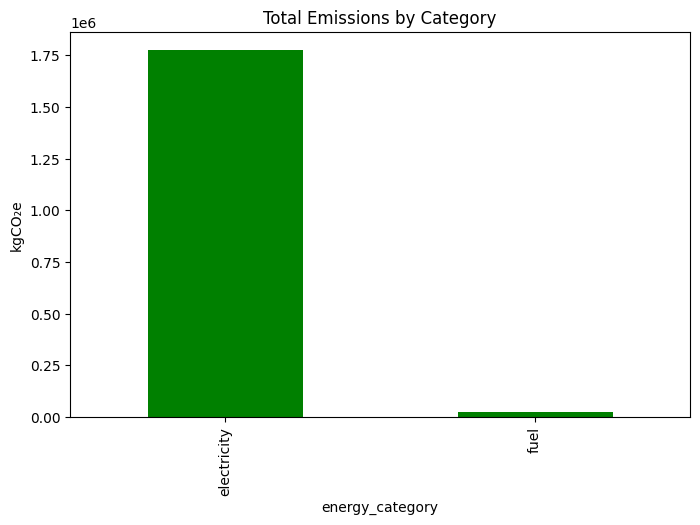

In [47]:
import matplotlib.pyplot as plt

df.groupby("energy_category")["emissions_kgCO2e"].sum().plot(
    kind="bar", figsize=(8,5), title="Total Emissions by Category",color = "green"
)
plt.ylabel("kgCO₂e")
plt.show()


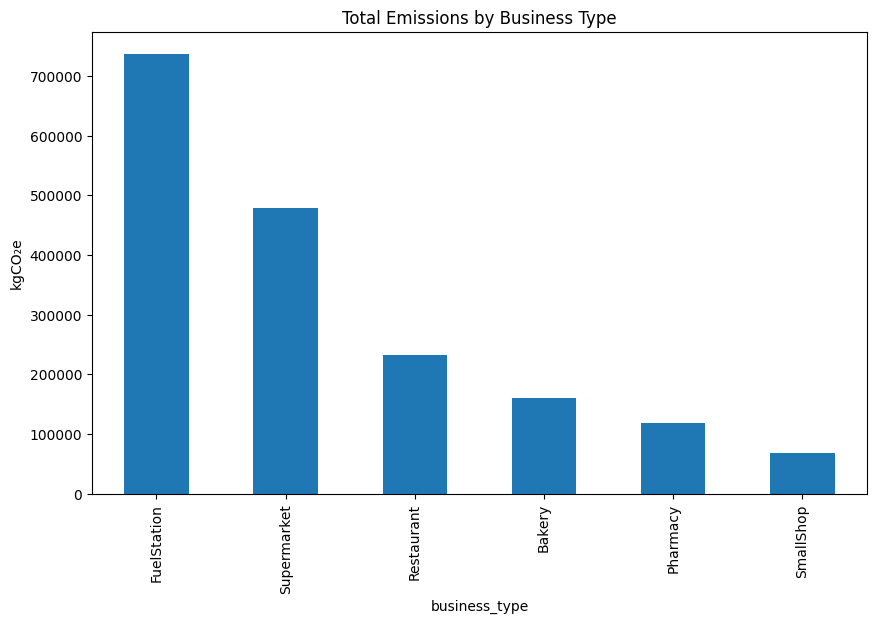

In [48]:
df.groupby("business_type")["emissions_kgCO2e"].sum().sort_values(ascending=False).plot(
    kind="bar", figsize=(10,6), title="Total Emissions by Business Type"
)
plt.ylabel("kgCO₂e")
plt.show()


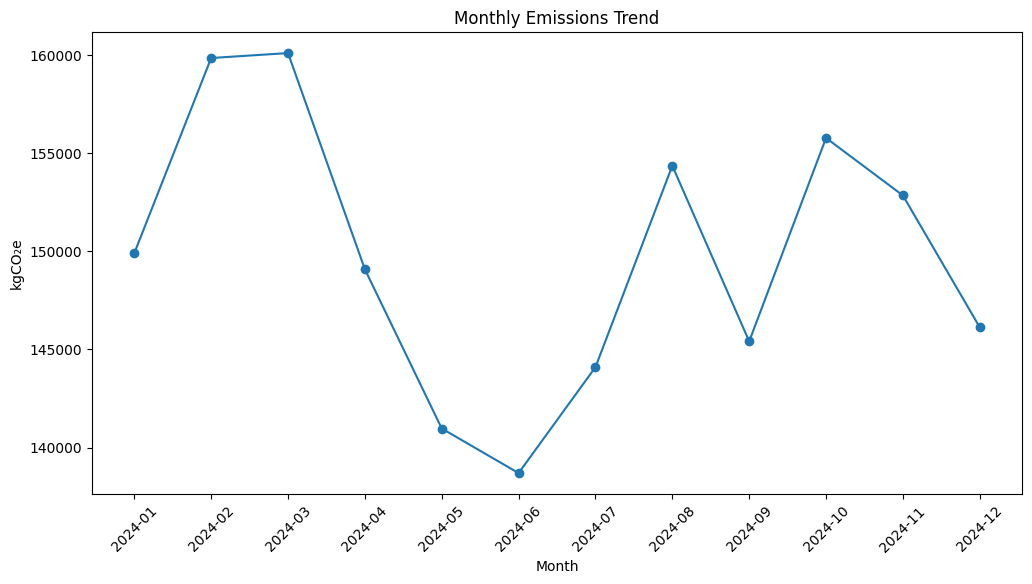

In [49]:
monthly = df.groupby("date")["emissions_kgCO2e"].sum().reset_index()

plt.figure(figsize=(12,6))
plt.plot(monthly["date"], monthly["emissions_kgCO2e"], marker="o")
plt.title("Monthly Emissions Trend")
plt.xlabel("Month")
plt.ylabel("kgCO₂e")
plt.xticks(rotation=45)
plt.show()


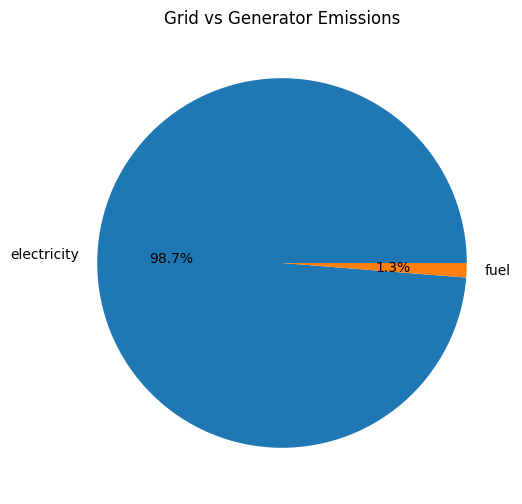

In [50]:
df.groupby("source_type")["emissions_kgCO2e"].sum().plot(
    kind="pie", autopct="%.1f%%", figsize=(6,6))
plt.title("Grid vs Generator Emissions")
plt.ylabel("")
plt.show()


In [51]:
print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1467 entries, 0 to 1466
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   business_id       1467 non-null   object 
 1   business_type     1467 non-null   object 
 2   consumption_kWh   1467 non-null   float64
 3   source            1440 non-null   object 
 4   activity          1440 non-null   object 
 5   unit              1467 non-null   object 
 6   emission_factor   1467 non-null   float64
 7   emissions_kgCO2e  1467 non-null   float64
 8   source_type       1467 non-null   object 
 9   fuel_type         27 non-null     object 
 10  liters            1467 non-null   float64
 11  date              1467 non-null   object 
 12  energy_category   1467 non-null   object 
dtypes: float64(4), object(9)
memory usage: 149.1+ KB
None
  business_id business_type  consumption_kWh     source             activity  \
0       B0001        Bakery           2022.0     

<Axes: title={'center': 'Top 5 Businesses by Emissions'}, xlabel='business_id'>

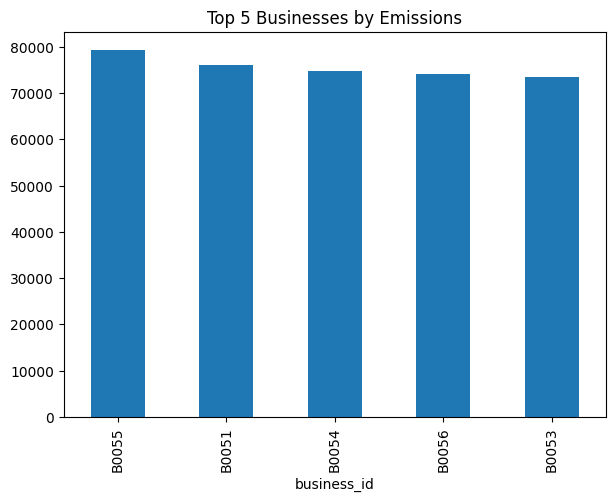

In [52]:
top5 = df.groupby("business_id")["emissions_kgCO2e"].sum().nlargest(5)
top5.plot(kind="bar", figsize=(7,5), title="Top 5 Businesses by Emissions")
